In [73]:
import jax
import jax.numpy as jnp

jax.config.update('jax_enable_x64', True)

In [74]:
from functools import partial
from pathlib import Path

import astropy.units as u
import croissant as cro
import healpy as hp
import matplotlib.pyplot as plt
import numpy as np
import scipy.sparse.linalg as sla
from astropy.time import Time

import mistsim as ms

%matplotlib widget

## 1. Define simulation

In [75]:
DATA_DIR = Path(
    "/home/christian/Documents/research/MIST/mistsim/notebooks/data/"
)

# sky
d = np.load(DATA_DIR / Path("haslam_galactic.npz"))
nside = d["nside"].item()
haslam_onefreq = d["m"][-1]
f = d["freqs"][-1]
print(f)

def scale_map(m, freqs, beta=-2.55, f0=408, tcmb=2.725):
    scale = (freqs/f0)**beta
    return (m-tcmb)[None, :] * scale[:, None] + tcmb

freqs = np.arange(25, 126)
haslam = scale_map(haslam_onefreq, freqs)
print(haslam.shape, nside)

# this is the frequency of the simulation
FREQ_IX = 0
sim_freq = freqs[FREQ_IX]
print(f"Simulation frequency = {sim_freq:.0f} MHz")

sky_map = haslam[FREQ_IX]
sky = ms.Sky(sky_map[None], sim_freq, sampling="healpix", coord="galactic")

# forward sim params
tstart = Time("2026-02-25 12:27")
tend = tstart + 1*u.sday  # one sidereal day
times = cro.utils.time_array(t_start=tstart, t_end=tend, N_times=500)
lmax = 179  # theoretical max

# create x vector
sky_alm = sky.compute_alm_eq(world="earth")
sky_alm = cro.utils.reduce_lmax(sky_alm, lmax)
x = ms.mapmaking.pack_s2fft_to_real(sky_alm)

125.0
(101, 196608) 128
Simulation frequency = 25 MHz


In [76]:
def alm1d_to_hp(alm):
    """
    Convert alm 1d with real/imag parts to healpy ordering
    """
    s = len(alm)  # one freq only for now
    lmax = int(np.sqrt(s) - 1)
    hp_len = hp.Alm.getsize(lmax)
    alm0 = alm[:lmax+1]
    almre = alm[lmax+1:hp_len]
    almim = alm[hp_len:]
    almc = 1/np.sqrt(2) * (almre + 1j*almim)
    return jnp.concatenate((alm0, almc))

x_hp = alm1d_to_hp(x)

In [77]:
LDIR = DATA_DIR / "20240806_for_lisa"

# mars beam
d = np.load(LDIR / "csa2022_beam2.npz")
assert np.allclose(d["freqs"], freqs)
gain = d["gain"]
theta = d["theta"]
horizon = theta <= 80  # mountains
g = gain[FREQ_IX]
mars_beam = ms.Beam(
    g[None],
    sim_freq,
    sampling="mwss",
    horizon=horizon[:, None],
    beam_az_rot=80,
)

# nevada beam
d = np.load(LDIR / "jackpot_beam2.npz")
assert np.allclose(d["freqs"], freqs)
gain = d["gain"]
theta = d["theta"]
g = gain[FREQ_IX]
# no mountain blockage!
nv_beam = ms.Beam(
    g[None], sim_freq, sampling="mwss", horizon=None, beam_az_rot=26
)

In [78]:
# mars
lon = -90.74750
lat = 79.41833
alt = 150

sim_mars = ms.Simulator(mars_beam, sky, times.jd, sim_freq, lon, lat, alt=alt, lmax=lmax)
A_mars = ms.mapmaking.make_Amat(sim_mars)

# nevada
lat = 37.21333
lon = -117.09111
alt = 0

sim_nv = ms.Simulator(nv_beam, sky, times.jd, sim_freq, lon, lat, alt=alt, lmax=lmax)
A_nv = ms.mapmaking.make_Amat(sim_nv)

In [79]:
def _rmatvec_stack(A1, A2, v):
    m1, n = A1.shape
    m2, n2 = A2.shape
    v1 = v[:m1]
    v2 = v[m1:]
    return A1.rmatvec(v1) + A2.rmatvec(v2)
    
def stack_As(A1, A2):
    """
    Stack A matrices defined by scipy.sparse.linalg.LinearOperator

    Parameters
    ----------
    A1 : LinearOperator
        Shape is (M1, N)
    A2 : LinearOperator
        Shape is (M2, N)
    

    Returns
    -------
    Astack : LinearOperator
        Vertically stacked A1, A2, shape is (M1+M2, N)

    """
    m1, n = A1.shape
    m2, n2 = A2.shape
    if not n == n2:
        raise ValueError("Incompatible shapes")
    shape = (m1+m2, n)
    matvec = lambda v: np.concatenate((A1.matvec(v), A2.matvec(v)), axis=0)
    rmatvec = lambda v: _rmatvec_stack(A1, A2, v)
    Astack = sla.LinearOperator(shape, matvec=matvec, rmatvec=rmatvec)
    return Astack

A = stack_As(A_mars, A_nv)

## 2. Run simulation, define noise and prior

In [80]:
y = A@x

# noise: radiometer
df = (freqs[1] - freqs[0]) * 1e6
dt = (times[1] - times[0]).to_value(u.s)
print(dt * df)
sigma = y.real / np.sqrt(dt * df)
Ndiag = sigma**2  # diag matrix

rng = np.random.default_rng(seed=1420)
noise = rng.normal(loc=0, scale=sigma)

172673528.11623126


In [81]:
len(times.jd)

500

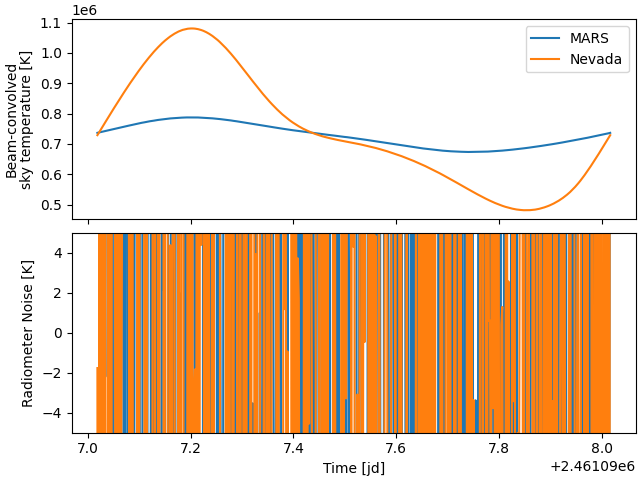

In [82]:
Ntimes = len(times)

fig, axs = plt.subplots(nrows=2, sharex=True, constrained_layout=True)
lines = axs[0].plot(times.jd, (y+noise).reshape(2, Ntimes).T)
axs[1].plot(times.jd, noise.reshape(2, Ntimes).T)
axs[0].set_ylabel("Beam-convolved\nsky temperature [K]")
axs[1].set_ylabel("Radiometer Noise [K]")
axs[1].set_xlabel("Time [jd]")
axs[1].set_ylim(-5, 5)
axs[0].legend(lines, ["MARS", "Nevada"])
plt.show()

In [83]:
def prior_ps(x):
    """
    Make prior be the true power spectrum of the sky

    Parameters
    ----------
    x : array_like
        Column vector

    """
    xhp = np.asarray(alm1d_to_hp(x))
    cl = hp.alm2cl(xhp)
    ells_hp, emms_hp = hp.Alm.getlm(lmax)
    ells_pos = ells_hp[emms_hp != 0]
    ells_full = np.concatenate((ells_hp, ells_pos))  # the m>=0 comes twice
    cl_full = cl[ells_full]
    return cl_full

Sdiag = prior_ps(x)
Sdiag.shape

(32400,)

True


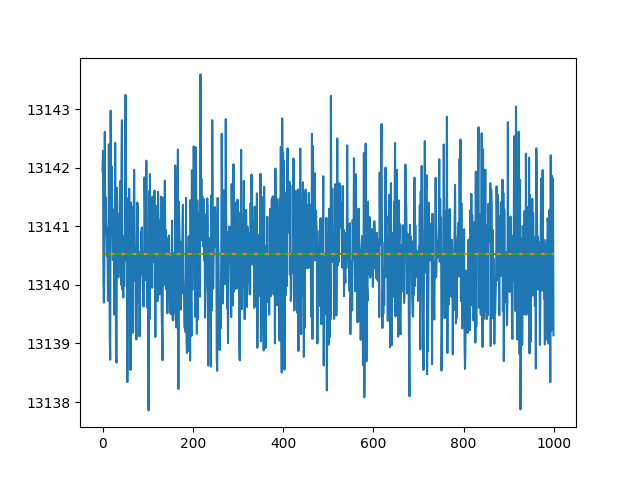

In [84]:
Atilde = ms.mapmaking.make_Atilde(Ndiag, A, Sdiag)
U_full, Sigma, Vh_full = sla.svds(Atilde, k=800)

# sort the u, s, v
svd_ix = np.argsort(Sigma)[::-1]
U_full = U_full[:, svd_ix]
Sigma = Sigma[svd_ix]
Vh_full = Vh_full[svd_ix]

xtilde = Sdiag**(-1/2) * x
ytilde = Ndiag**(-1/2) * y
ntilde = Ndiag**(-1/2) * noise

# confirm we got Ax = y still
print(np.allclose(Atilde @ xtilde, ytilde))

plt.figure()
plt.plot(ytilde+ntilde)
plt.plot(ytilde)
plt.plot(Atilde@xtilde, ls="--")
plt.show()

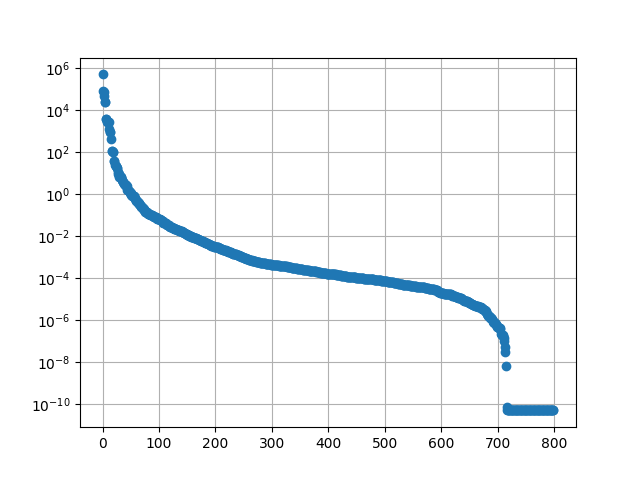

In [86]:
plt.figure()
plt.plot(Sigma, ls="none", marker="o")
plt.yscale("log")
plt.grid()
plt.show()

6.728630316265512e-09 7.394087935662698e-11


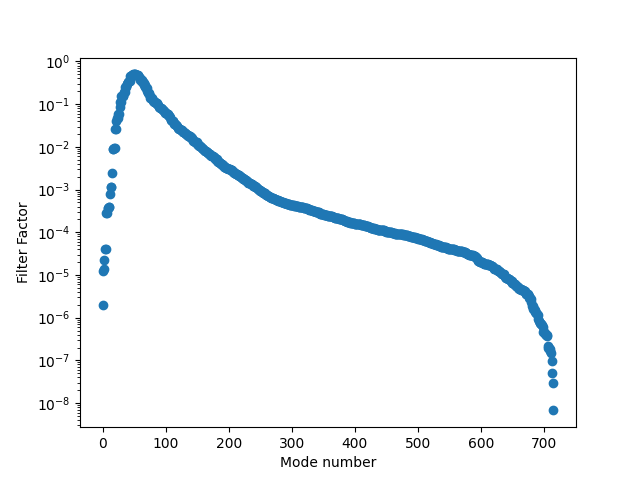

In [87]:
nvec = 716
print(Sigma[nvec-1], Sigma[nvec])
Dnum = Sigma[:nvec]
Dden = 1 + Dnum**2
D = Dnum / Dden
U = U_full[:, :nvec]
Vh = Vh_full[:nvec]

plt.figure()
plt.plot(np.arange(nvec), D[:nvec], ls="none", marker="o")
plt.ylabel("Filter Factor")
plt.xlabel("Mode number")
plt.yscale("log")
plt.show()

In [88]:
W_tilde = Vh.T @ np.diag(D) @ U.T  # VDU^T
y_tilde = Ndiag**(-1/2) * (y+noise)
x_tilde = W_tilde @ y_tilde
xh_svd = Sdiag**(1/2) * x_tilde
xh_svd_hp = alm1d_to_hp(xh_svd)

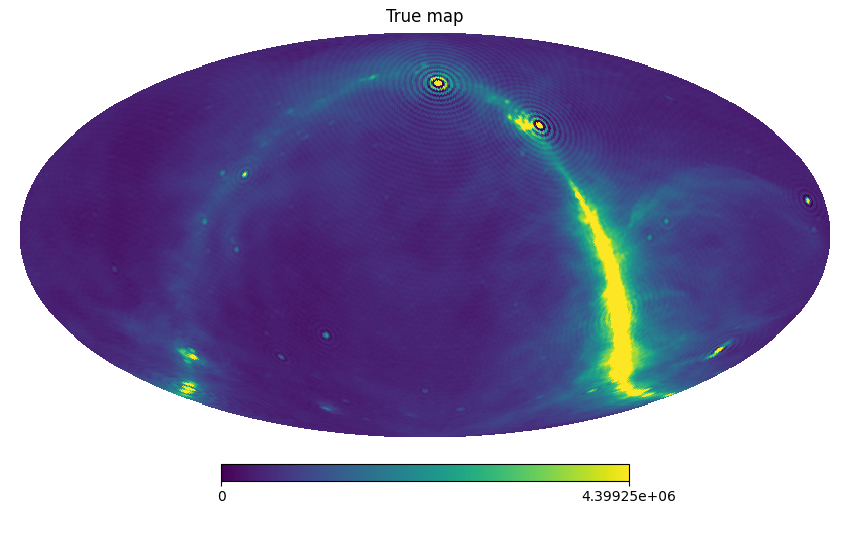

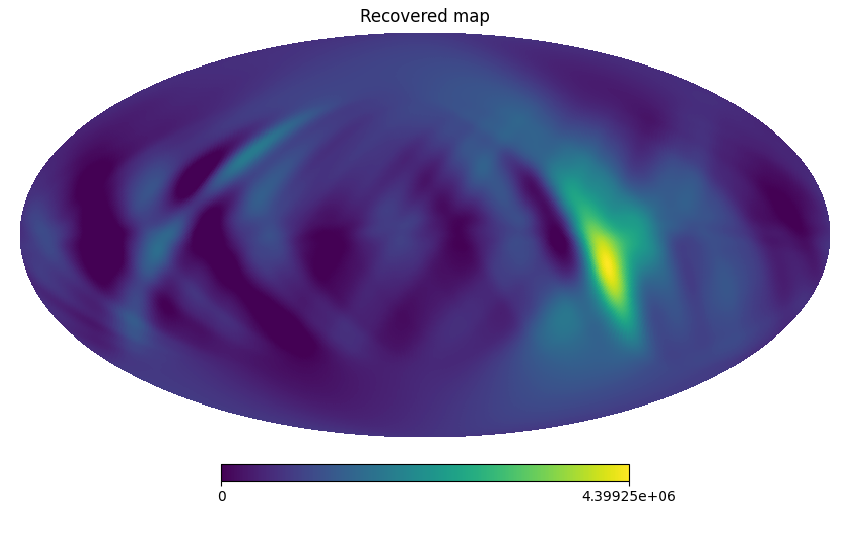

In [89]:
best_map = hp.alm2map(xh_svd_hp, nside)
vmax = best_map.max()

hp.mollview(hp.alm2map(x_hp, nside), title="True map", min=0, max=vmax)
plt.show()
hp.mollview(best_map, title="Recovered map", min=0, max=vmax)
plt.show()

In [90]:
nvar = 1000

# generate 1000 random alm's
wfull = np.random.normal(size=(Atilde.shape[1], nvar))  # variance = 1

# compute the posterior standard deviation in the SVD basis
post_std_svd = 1.0 / np.sqrt(Dnum**2 + 1.0)  # 1/(sigma**2+1)
std_reduce = 1 - post_std_svd  # this is reduced variance in posterior

# compute reduced-variance noise
corr = Vh.T @ (std_reduce[:, None] * (Vh @ wfull))
x_tilde_sim = wfull - corr  # subtract corection

# back to harmonic coefficients
x_sim = np.sqrt(Sdiag)[:, None] * x_tilde_sim
x_sim_hp = np.array(
    [
        hp.alm2map(
            alm1d_to_hp(x_sim[:, i]), nside
        ) for i in range(x_sim.shape[-1])
    ]
)

# posterior std
std_map = np.std(x_sim_hp, axis=0)

# prior power spectrum
cl_prior = hp.alm2cl(np.asarray(x_hp))
ell = np.arange(len(cl_prior))
sigma2_prior = np.sum((2 * ell + 1) / (4 * np.pi) * cl_prior)
print(f"Prior standard deviation = {np.sqrt(sigma2_prior):.1f} K")

Prior standard deviation = 1275018.8 K


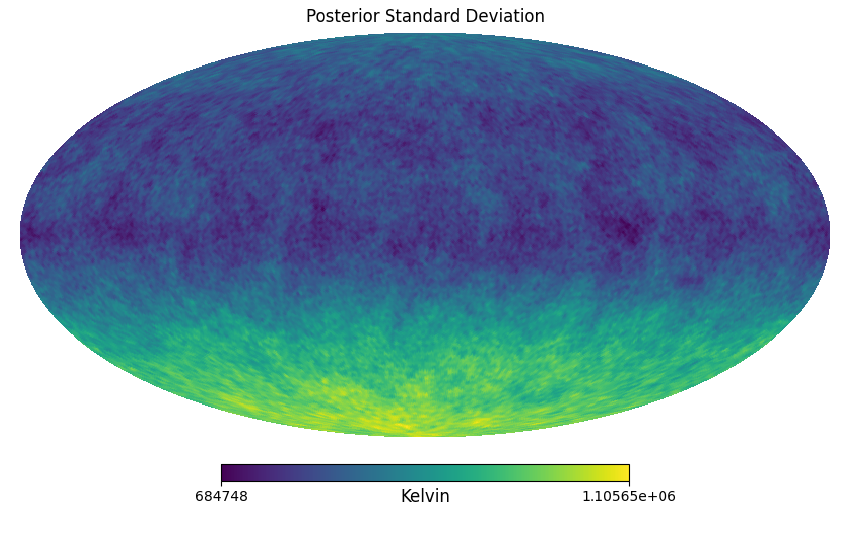

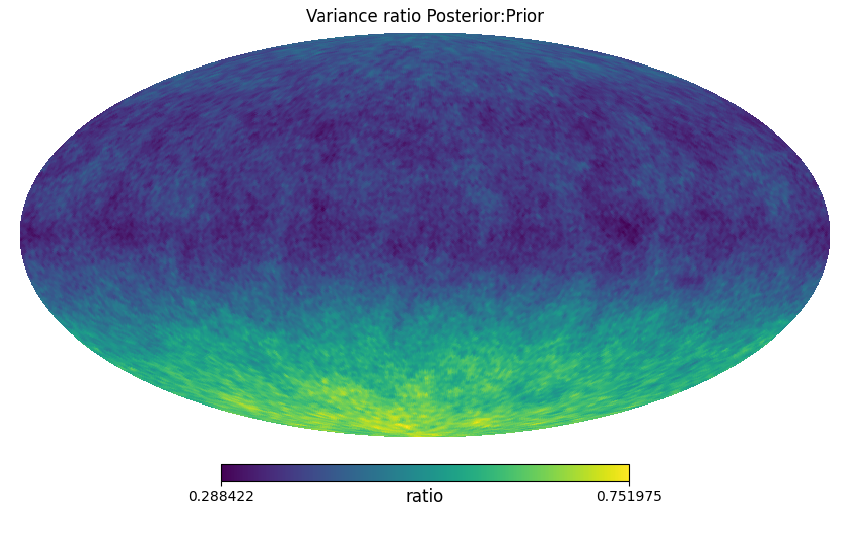

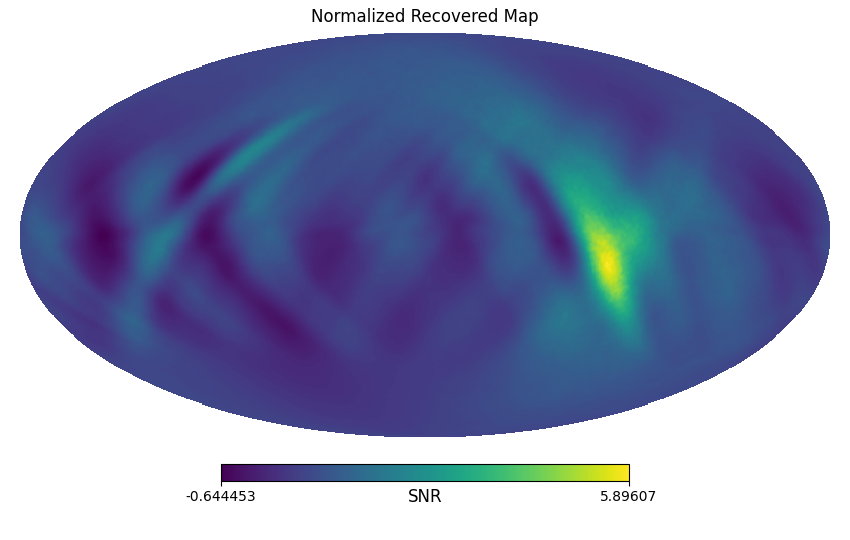

In [91]:
hp.mollview(std_map, title="Posterior Standard Deviation", unit="Kelvin")
plt.show()
hp.mollview(
    std_map**2/sigma2_prior,
    title="Variance ratio Posterior:Prior",
    unit="ratio",
)
plt.show()
hp.mollview(best_map/std_map, title="Normalized Recovered Map", unit="SNR")
plt.show()